# Unsupervised Machine Mearning A1 Assignement

### Aicha Dieng




# Business Case

For this project, I used the NYC Citywide Payroll Dataset from NYC Open Data, which includes payroll information for all New York City municipal employees for Fiscal Year 2024.

The dataset contains 17 columns covering information such as base salary, overtime hours, gross pay, and total compensation across different agencies and job titles.

Dataset:
https://data.cityofnewyork.us/City-Government/Citywide-Payroll-Data-Fiscal-Year-/k397-673e

I chose this dataset because overtime in public sector jobs has always been something I found interesting. New York City's FY2024 budget reached $107 billion; the largest in city history (City & State NY, 2023)  and a large portion of that goes directly to employee compensation, including overtime pay. The NYC Comptroller's Office even published a dedicated report highlighting NYPD overtime as a growing financial concern for the city (NYC Comptroller, 2023).

As someone entering the workforce soon, I wanted to understand how compensation actually works in large organizations, and whether overtime is being used efficiently or if certain agencies are over-relying on it.

The goal of this analysis is to explore the data, clean it, and identify patterns in how city employees are compensated. Are certain agencies paying excessive overtime compared to their base salaries? Are there natural groupings of employees based on how they get paid? What factors actually drive total compensation? Ultimately, the findings of this analysis could shed light on whether excessive overtime is a sign of understaffing in certain areas and what that means for employment and workforce planning in New York City.


Sources:

City & State NY (2023): https://www.cityandstateny.com/policy/2023/06/fiscal-year-2024-new-york-city-budget-numbers/388113/


NYC Comptroller (2023): https://comptroller.nyc.gov/reports/overtime-overview/





# Data Cleaning

In [1]:
import pandas as pd

# Load 100,000 rows from the NYC Open Data API for Fiscal Year 2024, then randomly sample 50,000 for manageability
url = "https://data.cityofnewyork.us/resource/k397-673e.csv?$limit=100000&$where=fiscal_year='2024'"
df = pd.read_csv(url)
df = df.sample(n=50000, random_state=42)

print(df.shape)
print(df.dtypes)

(50000, 17)
fiscal_year                     int64
payroll_number                  int64
agency_name                    object
last_name                      object
first_name                     object
mid_init                       object
agency_start_date              object
work_location_borough          object
title_description              object
leave_status_as_of_june_30     object
base_salary                   float64
pay_basis                      object
regular_hours                 float64
regular_gross_paid            float64
ot_hours                      float64
total_ot_paid                 float64
total_other_pay               float64
dtype: object


In [2]:
print(df.isnull().sum())
print(df.head())

fiscal_year                       0
payroll_number                    0
agency_name                       0
last_name                         0
first_name                        0
mid_init                      14577
agency_start_date                 0
work_location_borough             0
title_description                 0
leave_status_as_of_june_30        0
base_salary                       0
pay_basis                         0
regular_hours                     0
regular_gross_paid                0
ot_hours                          0
total_ot_paid                     0
total_other_pay                   0
dtype: int64
       fiscal_year  payroll_number        agency_name        last_name  \
75721         2024              57    FIRE DEPARTMENT  GONZALEZ-MORILL   
80184         2024              57    FIRE DEPARTMENT          SCANLON   
19864         2024              56  POLICE DEPARTMENT            SCOTT   
76699         2024              57    FIRE DEPARTMENT           CARNEY   
92991

In [3]:
# Drop irrelevant columns
df = df.drop(columns=['last_name', 'first_name', 'mid_init', 'payroll_number'])

# Extract year from agency_start_date
df['agency_start_year'] = pd.to_datetime(df['agency_start_date']).dt.year
df = df.drop(columns=['agency_start_date'])

print(df.shape)
print(df.dtypes)

(50000, 13)
fiscal_year                     int64
agency_name                    object
work_location_borough          object
title_description              object
leave_status_as_of_june_30     object
base_salary                   float64
pay_basis                      object
regular_hours                 float64
regular_gross_paid            float64
ot_hours                      float64
total_ot_paid                 float64
total_other_pay               float64
agency_start_year               int32
dtype: object


The dataset was first cleaned by dropping columns that were not relevant to the analysis. No missing values were found across any column, so no imputation was required. The columns last_name, first_name, mid_init, and payroll_number were removed because they are personal identifiers that do not contribute to understanding compensation or overtime patterns. The agency_start_date column was converted into a numerical variable by extracting just the year, which is more useful for analysis. After cleaning, the dataset contains 50,000 rows and 13 columns, with 8 numerical columns representing 61.5% of the dataset.



## Exploratory Data Analysis (EDA)

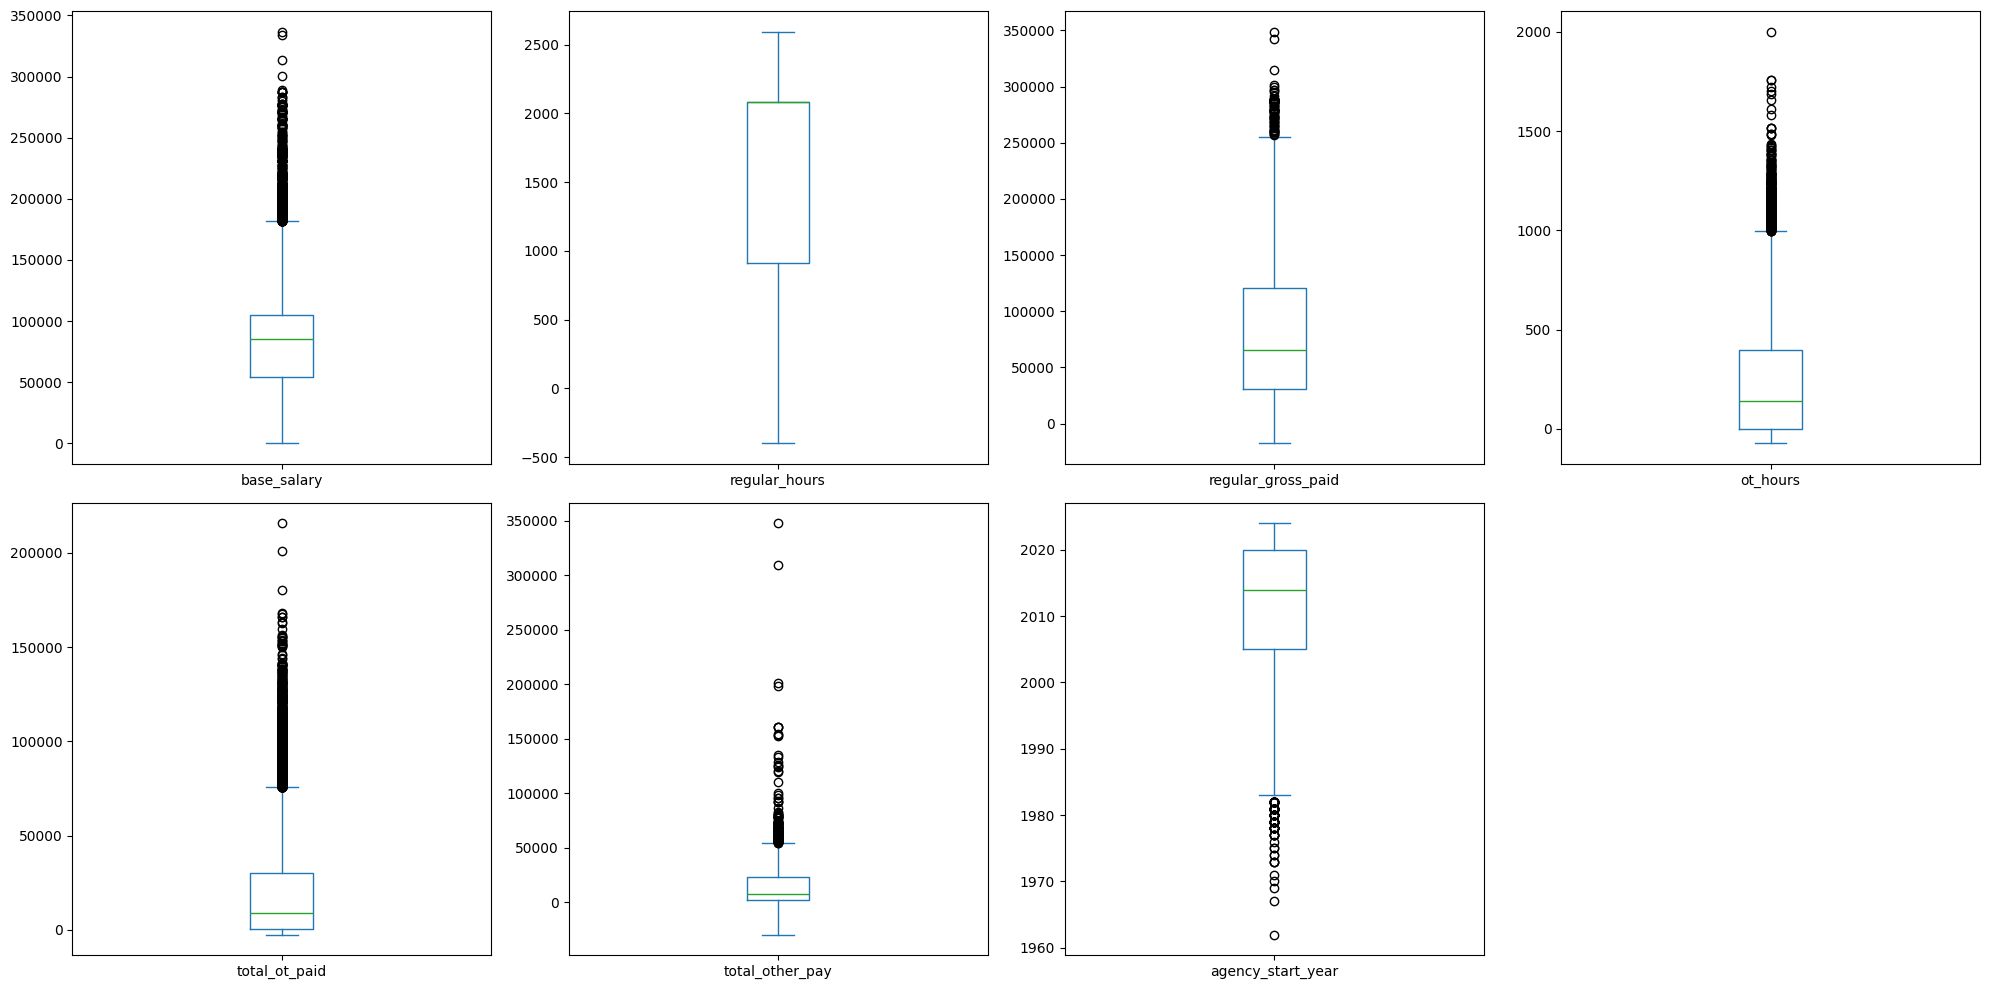

In [4]:
import matplotlib.pyplot as plt

numerical_cols = ['base_salary', 'regular_hours', 'regular_gross_paid',
                  'ot_hours', 'total_ot_paid', 'total_other_pay', 'agency_start_year']

df[numerical_cols].plot(kind='box', subplots=True, layout=(2,4),
                         figsize=(20,10))
plt.tight_layout()
plt.show()

In [5]:
df[numerical_cols].describe()

,base_salary,regular_hours,regular_gross_paid,ot_hours,total_ot_paid,total_other_pay,agency_start_year
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,82700.968742,1515.233642,76180.457331,227.090416,19093.499183,12657.827645,2012.143340
std,39811.436237,827.669720,54419.976063,258.052501,24267.395284,12783.203657,9.195464
min,1.000000,-400.000000,-17473.500000,-72.000000,-2512.420000,-29498.590000,1962.000000
25%,53790.000000,910.000000,30532.170000,0.000000,181.915000,1906.292500,2005.000000
50%,85600.000000,2080.000000,65541.530000,139.750000,8722.535000,7638.250000,2014.000000
75%,105146.000000,2080.000000,120703.540000,399.250000,30360.457500,22971.345000,2020.000000
max,336563.000000,2592.500000,348737.370000,1999.270000,215680.310000,347512.730000,2024.000000


In [6]:
# Fix negatives first
cols_no_negative = ['regular_hours', 'regular_gross_paid', 'ot_hours',
                    'total_ot_paid', 'total_other_pay']
df[cols_no_negative] = df[cols_no_negative].clip(lower=0)

# Then cap outliers
cols_to_cap = ['base_salary', 'regular_gross_paid', 'total_ot_paid',
               'ot_hours', 'total_other_pay']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)


df[cols_to_cap].describe()

,base_salary,regular_gross_paid,total_ot_paid,ot_hours,total_other_pay
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,82190.741168,76151.686492,18459.587396,225.873959,12594.579478
std,38168.358009,54275.141456,22248.844494,253.662680,12262.462460
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,53790.000000,30532.170000,181.915000,0.000000,1906.292500
50%,85600.000000,65541.530000,8722.535000,139.750000,7638.250000
75%,105146.000000,120703.540000,30360.457500,399.250000,22971.345000
max,182180.000000,255960.595000,75628.271250,998.125000,54568.923750


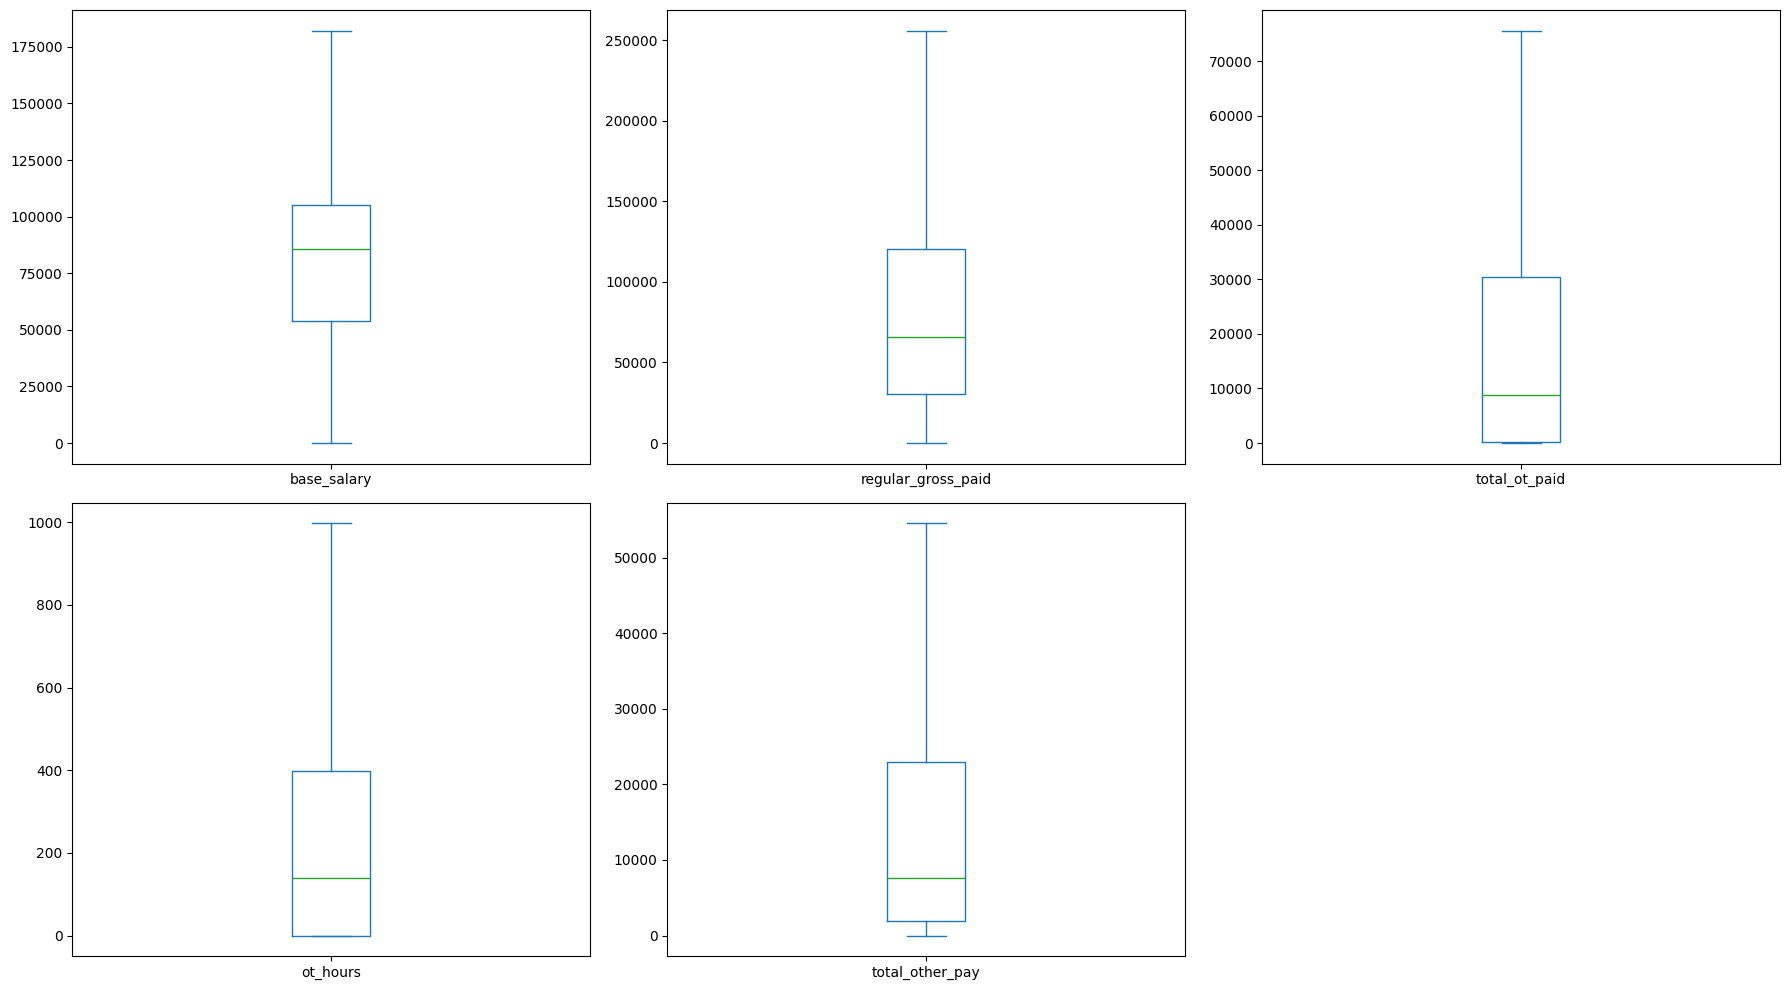

In [7]:
df[cols_to_cap].plot(kind='box', subplots=True, layout=(2,3),
                      figsize=(18,10))
plt.tight_layout()
plt.show()

The dataset required two cleaning steps:

First, several columns including regular_hours, regular_gross_paid, ot_hours, total_ot_paid, and total_other_pay contained negative values. In government payroll systems, negative values typically represent corrections for previous overpayments. Since these records still represent real employees, I replaced negative values with 0 rather than deleting the rows.


Second, the same columns plus base_salary had extreme high values that would distort the analysis. I chose to cap rather than delete because high overtime earners are real and relevant to my business question so removing them would erase exactly the cases I am trying to study.

Since removing the negatives shifted the overall distribution upward, the capping threshold also adjusted accordingly, bringing the extreme values into a more balanced range. The boxplots confirm that after cleaning, the distributions are much more balanced with no extreme outliers remaining.

# Data Transformation  

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['base_salary', 'regular_hours', 'regular_gross_paid',
                  'ot_hours', 'total_ot_paid', 'total_other_pay', 'agency_start_year']

df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df_scaled[numerical_cols].describe().round(2)

,base_salary,regular_hours,regular_gross_paid,ot_hours,total_ot_paid,total_other_pay,agency_start_year
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.15,-1.83,-1.40,-0.89,-0.83,-1.03,-5.45
25%,-0.74,-0.73,-0.84,-0.89,-0.82,-0.87,-0.78
50%,0.09,0.68,-0.20,-0.34,-0.44,-0.40,0.20
75%,0.60,0.68,0.82,0.68,0.53,0.85,0.85
max,2.62,1.30,3.31,3.04,2.57,3.42,1.29


All numerical columns were standardized using StandardScaler. Before scaling, columns like base_salary were in the hundreds of thousands while ot_hours was in the hundreds; the ranges were very different. I chose StandardScaler over MinMax because the data still has a wide range even after capping, and StandardScaler is more robust in that situation.Without scaling, PCA and clustering would treat salary as more important simply because the numbers are larger, not because it is actually more significant. After scaling, every column has a mean of 0 and a standard deviation of 1, putting them all on the same scale.

# Feature Selection

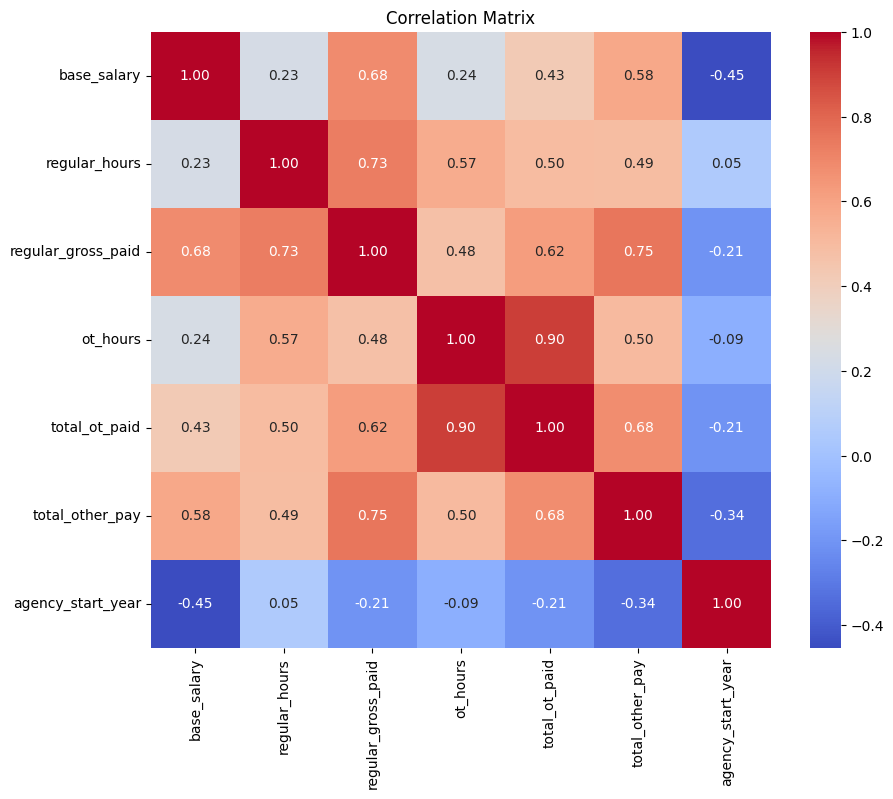

In [10]:
import seaborn as sns

corr_matrix = df_scaled[numerical_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [16]:
features = ['base_salary', 'regular_gross_paid', 'total_ot_paid',
            'total_other_pay', 'agency_start_year']

df_pca = df_scaled[features]
print(df_pca.shape)

(50000, 5)


To select the most relevant features for this analysis, a correlation matrix was generated on the scaled numerical columns. Features with high correlation coefficients were identified as redundant and removed to avoid multicollinearity, which can distort PCA and clustering results.
Two features were dropped:

1. regular_hours was dropped because regular_gross_paid already captures the same information; it is the product of hours worked and pay rate, acting as a natural interaction term (r=0.73). Keeping both would double-weight this information.

2. ot_hours was dropped in favour of total_ot_paid (r=0.90). Since this analysis focuses on compensation costs rather than time worked, the dollar value of overtime is more meaningful than the number of hours.

The 5 features retained each capture a distinct dimension of employee compensation:

* base_salary: the employee's baseline compensation level

* regular_gross_paid: actual regular earnings, capturing both hours worked and pay rate

* total_ot_paid: overtime spending in dollars, directly relevant to the business question

* total_other_pay: supplemental compensation such as bonuses and differentials

* agency_start_year: employee seniority and tenure within the agency

# Interaction Terms

In [15]:
# Interaction Terms
df_pca = df_pca.copy()

# 1. Overtime burden: how much overtime pay relative to base salary
df_pca['ot_to_base_ratio'] = df_scaled['total_ot_paid'] * df_scaled['base_salary']

# 2. Total compensation mix: regular pay + other pay
df_pca['total_compensation'] = df_scaled['regular_gross_paid'] * df_scaled['total_other_pay']

print(df_pca.shape)
print(df_pca.head())

(50000, 7)
       base_salary  regular_gross_paid  total_ot_paid  total_other_pay  \
75721    -0.270849           -1.361117      -0.809257        -1.016127   
80184    -0.827572           -1.403082      -0.829696        -0.637989   
19864    -2.152910           -1.005610      -0.829696        -0.956390   
76699     0.337305           -1.350975      -0.748038        -0.969424   
92991     0.601427            0.820860      -0.292262         1.205997   

       agency_start_year  ot_to_base_ratio  total_compensation  
75721          -0.994341          0.219186            1.383067  
80184          -0.341839          0.686633            0.895151  
19864           0.201912          1.786260            0.961755  
76699          -1.864344         -0.252317            1.309668  
92991          -0.668090         -0.175774            0.989955  


In [19]:
# Show top 5 highest overtime burden
print(df_pca.nlargest(5, 'ot_to_base_ratio'))

# Show top 5 lowest overtime burden
print(df_pca.nsmallest(5, 'ot_to_base_ratio'))

       base_salary  regular_gross_paid  total_ot_paid  total_other_pay  \
50451     2.619716            1.095085       2.569538         0.443974   
52747     2.619716            1.533155       2.281056         0.620586   
85036     2.216813            2.029165       2.569538         0.028027   
57335     2.155898            1.684853       2.569538         0.901240   
71010     2.155898            1.684853       2.569538         1.861516   

       agency_start_year  ot_to_base_ratio  total_compensation  
50451          -0.668090          6.731460            0.486189  
52747          -0.668090          5.975719            0.951455  
85036          -2.190595          5.696185            0.056870  
57335          -0.776841          5.539662            1.518457  
71010          -1.538093          5.539662            3.136380  
       base_salary  regular_gross_paid  total_ot_paid  total_other_pay  \
90310    -2.143158            0.542522       2.569538         0.935059   
95951    -2.14315

In [20]:
# Show top 5 highest overtime burden
print(df_pca.nlargest(5, 'total_compensation'))

# Show top 5 lowest overtime burden
print(df_pca.nsmallest(5, 'total_compensation'))

       base_salary  regular_gross_paid  total_ot_paid  total_other_pay  \
96009     2.619716            2.445637      -0.829696         3.423029   
96012     2.619716            2.445637      -0.829696         3.423029   
95964     2.619716            2.445637      -0.829696         3.042964   
95897     2.619716            2.445637      -0.829696         2.831329   
73999     2.619716            2.714805      -0.829696         2.520057   

       agency_start_year  ot_to_base_ratio  total_compensation  
96009          -1.864344         -2.173567            8.371487  
96012          -2.951848         -2.173567            8.371487  
95964          -2.625597         -2.173567            7.441987  
95897          -2.408096         -2.173567            6.924404  
73999          -2.734347         -2.173567            6.841463  
       base_salary  regular_gross_paid  total_ot_paid  total_other_pay  \
74579     2.619716           -1.403082      -0.829696         3.423029   
708       1.18036

The two interaction terms reveal a pattern that directly connects to the business question of whether NYC agencies are over-relying on overtime.

The first term, **ot_to_base_ratio**, demonstrates that employees with the highest overtime burden are already high-salaried workers who are also earning significant overtime pay. This indicates that the city is effectively paying certain employees twice their already substantial salary which is particularly concerning given that the NYC Comptroller has flagged overtime spending, especially within the NYPD, as a growing financial burden.

 The second term, **total_compensation**, reveals that certain employees are being compensated heavily from multiple sources: strong regular earnings combined with significant bonuses.

 Together, these two interaction terms highligh a two-sided problem:

 some employees are expensive from every angle:  high salary, high overtime, and high bonuses, while the city's budget continues to grow.

 This raises a critical question:

 **Is overtime being used because there are genuinely not enough staff to cover shifts, or is it a structural inefficiency where the same high-salaried employees continue to accumulate compensation from multiple directions?**





# Principal Component Analysis (PCA)

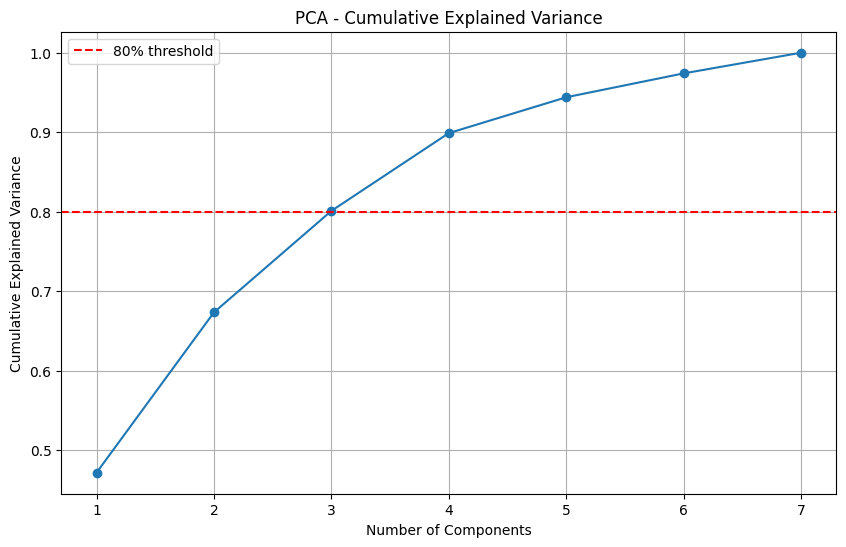

[0.47182448 0.2016293  0.12761721 0.0978013  0.04510727 0.0300415
 0.02597894]
[0.47182448 0.67345377 0.80107098 0.89887228 0.94397955 0.97402106
 1.        ]


In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit PCA
pca = PCA()
pca.fit(df_pca)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

print(explained_variance)
print(cumulative_variance)

Original shape: (50000, 7)
Reduced shape: (50000, 3)
Total variance explained: 80.11%

Variance explained per component:
  PC1: 47.18%
  PC2: 20.16%
  PC3: 12.76%

PCA Weights:
     base_salary  regular_gross_paid  total_ot_paid  total_other_pay  \
PC1     0.430032            0.481358       0.452830         0.504932   
PC2    -0.413229           -0.116421       0.334300         0.035329   
PC3     0.051390            0.383290       0.148813         0.070124   

     agency_start_year  ot_to_base_ratio  total_compensation  
PC1          -0.267499          0.128032            0.188168  
PC2           0.313409          0.717019            0.300571  
PC3           0.802197         -0.168473           -0.389208  


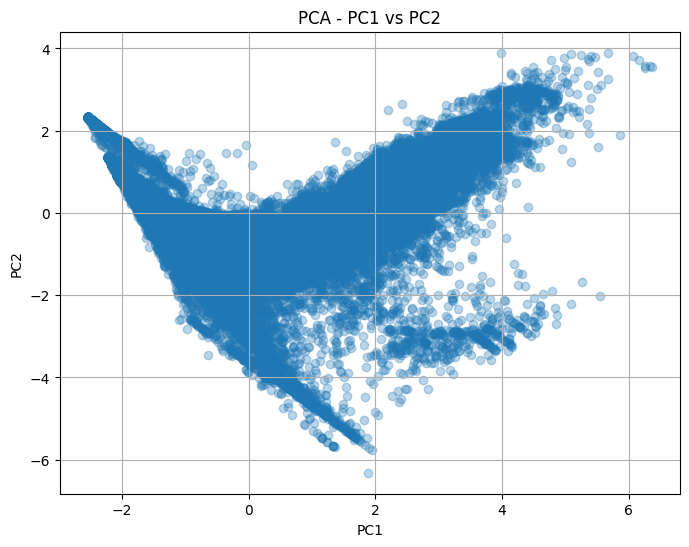

In [24]:
# Apply PCA with 3 components
pca = PCA(n_components=3)
df_pca_reduced = pca.fit_transform(df_pca)

print(f"Original shape: {df_pca.shape}")
print(f"Reduced shape: {df_pca_reduced.shape}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Variance per component
print("\nVariance explained per component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.2%}")

# PCA weights table
component_weights = pd.DataFrame(
    data=pca.components_,
    columns=df_pca.columns,
    index=[f'PC{i+1}' for i in range(3)]
)
print("\nPCA Weights:")
print(component_weights)

# Scatter plot PC1 vs PC2
pca_df = pd.DataFrame(df_pca_reduced, columns=['PC1', 'PC2', 'PC3'])

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - PC1 vs PC2')
plt.grid(True)
plt.show()

I applied PCA to reduce the 7 features in df_pca down to 3 principal components. Using a scree plot and an 80% variance threshold, I confirmed that 3 components capture 80.11% of the variance (PC1=47.18%, PC2=20.16%, PC3=12.76%), meaning the most meaningful patterns in the data are retained while noise is discarded.

The scatter plot of PC1 vs PC2 shows that employees naturally spread across distinct regions, confirming that real differences exist in compensation profiles across NYC agencies.

# Clustering

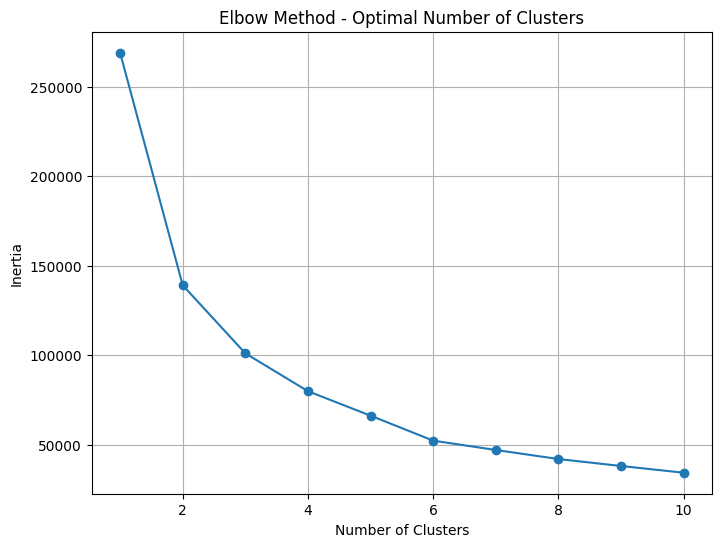

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca_reduced)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.grid(True)
plt.show()

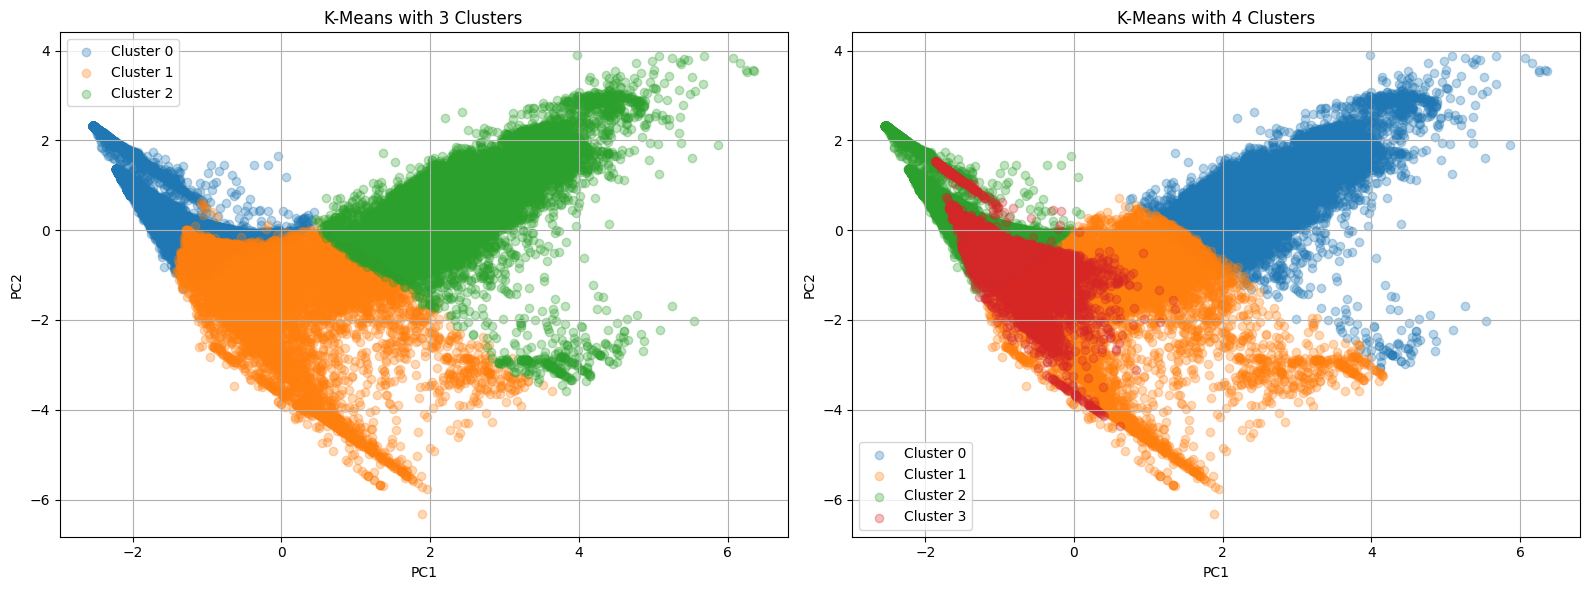

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, k in enumerate([3, 4]):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca_reduced)

    for cluster in range(k):
        mask = labels == cluster
        axes[idx].scatter(df_pca_reduced[mask, 0], df_pca_reduced[mask, 1],
                         alpha=0.3, label=f'Cluster {cluster}')

    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    axes[idx].set_title(f'K-Means with {k} Clusters')
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

In [28]:
# Apply K-means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(df_pca_reduced)

# Add cluster labels back to original scaled data
df_scaled['Cluster'] = kmeans.labels_

# Look at the average of each cluster using ORIGINAL features
cluster_summary = df_scaled.groupby('Cluster')[['base_salary', 'regular_gross_paid',
                                                  'total_ot_paid', 'total_other_pay',
                                                  'agency_start_year']].mean()
print(cluster_summary)

         base_salary  regular_gross_paid  total_ot_paid  total_other_pay  \
Cluster                                                                    
0          -0.859410           -0.681318      -0.534123        -0.702645   
1           0.483489           -0.134601      -0.490360        -0.223468   
2           0.839874            1.107964       1.197135         1.214917   

         agency_start_year  
Cluster                     
0                 0.718241  
1                -0.790431  
2                -0.372073  


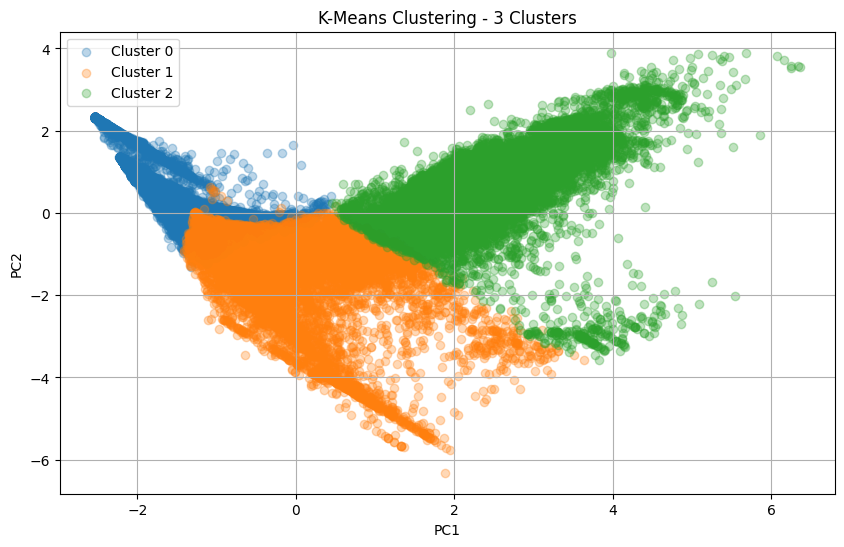

In [29]:
# Visualize final 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_pca_reduced)

plt.figure(figsize=(10, 6))
for cluster in range(3):
    mask = labels == cluster
    plt.scatter(df_pca_reduced[mask, 0], df_pca_reduced[mask, 1],
                alpha=0.3, label=f'Cluster {cluster}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering - 3 Clusters')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
print(component_weights)

     base_salary  regular_gross_paid  total_ot_paid  total_other_pay  \
PC1     0.430032            0.481358       0.452830         0.504932   
PC2    -0.413229           -0.116421       0.334300         0.035329   
PC3     0.051390            0.383290       0.148813         0.070124   

     agency_start_year  ot_to_base_ratio  total_compensation  
PC1          -0.267499          0.128032            0.188168  
PC2           0.313409          0.717019            0.300571  
PC3           0.802197         -0.168473           -0.389208  


The K-means clustering analysis revealed three distinct employee compensation profiles.
While the elbow plot suggested 3-4 clusters as the optimal range, 3 clusters were selected because they align directly with the business question. It provides three distinct and interpretable compensation profiles without adding unnecessary complexity.

- Cluster 0 (Low Compensation): Employees with below average overall compensation. When overtime occurs, it can spike significantly, suggesting these employees are being stretched to cover staffing gaps despite their lower pay. This is a strong signal of understaffing in certain agencies.

- Cluster 1 (Stable Middle): Employees with slightly above average salaries and minimal overtime. These represent the healthiest employment pattern; a stable compensation without excessive reliance on overtime.

- Cluster 2 (High Compensation + High Overtime): The most financially burdensome group for the city. These employees already command high salaries, yet also accumulate significant overtime pay. This directly supports the NYC Comptroller's concerns about growing overtime costs, particularly in agencies like the NYPD.

Together, these findings suggest that NYC's overtime spending problem is structural and is affecting both ends of the pay scale.

Low paid workers are working excessive overtime to fill staffing gaps, while high paid workers are accumulating costly overtime on top of already substantial salaries.

# Results and Conclusion

This analysis explored NYC FY2024 payroll data for 50,000 municipal employees with the goal of understanding whether certain agencies are over-relying on overtime, and whether this signals structural understaffing.

During data cleaning, negative values were corrected and outliers were capped rather than removed to preserve high overtime earners who are central to the business question.

Five key features were selected based on the correlation matrix:
- base_salary,
- regular_gross_paid,
- total_ot_paid,
- total_other_pay, and
- agency_start_year.

Two interaction terms were created to capture the true financial burden of overtime:

**ot_to_base_ratio** revealed that the city is effectively paying some high-salaried employees twice their already substantial salary in overtime, while **total_compensation** showed that certain employees are heavily compensated from multiple sources simultaneously.


PCA reduced the 7 features to 3 components capturing 80% of the variance. K-means clustering then identified 3 distinct employee profiles that directly answer the business question:

* Low Compensation:

 Lower-paid employees with overtime spikes. These workers are not choosing overtime; in NYC public sector jobs, overtime is supervisor-assigned and mandatory. This means these employees are being forced to fill staffing gaps despite lower pay. This is the clearest signal of understaffing.

* Stable Middle:

 Average compensation, minimal overtime. This is the healthiest employment pattern and represents what well-staffed agencies look like.

* High Compensation + High Overtime: Already high-salaried employees who are also accumulating significant overtime. The city is essentially paying these employees twice:  once in salary and once in overtime. This is the most expensive group and the biggest drain on NYC's budget.

The core finding of this analysis is that NYC's overtime problem is structural and affects both ends of the pay scale. The most cost-effective solution would be targeted hiring across agencies,  particularly where lower-paid employees are being stretched to cover gaps. For high-salary clusters, hiring additional junior staff would cost less than continuing to fund overtime for already expensive employees. Until staffing levels are addressed, NYC will continue paying a premium for the same work that additional hires could cover at a fraction of the cost.